In [ ]:
# ═══════════════════════════════════════════════════
# CELL 1 — Setup (Preprocessing)
# ═══════════════════════════════════════════════════
import sys
import os
import warnings

# Allow imports from project root (src/)
sys.path.append('..')

# Set CWD to project root
os.chdir("..")
print("CWD:", os.getcwd())

# Common libs
import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

print("✅ Setup complete (Preprocessing)")

✅ Modules loaded with force reload


In [4]:
# ═══════════════════════════════════════════════════
# CELL 1 — Setup
# ═══════════════════════════════════════════════════
import sys
sys.path.append('..')

from src.data.preprocessor import NetworkDataPreprocessor
from src.features.engineer import NetworkFeatureEngineer
from src.data.splitter import DataSplitter

print("✅ Modules loaded")


✅ Modules loaded


In [5]:
# ═══════════════════════════════════════════════════
# CELL 2 — Run Preprocessing Pipeline
# ═══════════════════════════════════════════════════
preprocessor = NetworkDataPreprocessor(
    raw_data_path="../data/raw/",
    processed_data_path="../data/processed/"
)

df = preprocessor.run_full_pipeline()


║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║
  NetSentinel — Data Preprocessing Pipeline
║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║

STEP 1: LOADING DATA
  Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
    → 288,602 rows
  Loading Monday-WorkingHours.pcap_ISCX.csv...
    → 529,918 rows
  Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
    → 191,033 rows
  Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
    → 286,467 rows
  Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
    → 225,745 rows
  Loading Tuesday-WorkingHours.pcap_ISCX.csv...
    → 445,909 rows
  Loading Wednesday-workingHours.pcap_ISCX.csv...
    → 692,703 rows
  Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
    → 170,366 rows

  ✅ Total: 2,830,743 rows, 79 columns

STEP 2: CLEANING COLUMN NAMES
  ✅ Columns standardized
  Example: ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets',

In [6]:
# ═══════════════════════════════════════════════════
# CELL 3 — Run Feature Engineering
# ═══════════════════════════════════════════════════
engineer = NetworkFeatureEngineer()
df = engineer.run_feature_engineering(df)

# Save updated processed data
df.to_csv("../data/processed/processed_traffic.csv", index=False)
print(f"\n✅ Updated processed data saved: {len(df):,} rows, {len(df.columns)} columns")


FEATURE ENGINEERING
  Found 0 mapped columns
  → Creating packet ratios...
  → Creating flag features...
  → Creating flow intensity features...
  → Creating entropy features...
  → Creating behavioral features...
  → Cleaning infinite values from new features...
    ✅ No infinite values found

  ✅ Feature engineering complete
     Columns before: 50
     Columns after:  51
     New features:   1

  New features created:
    → total_flags

✅ Updated processed data saved: 2,520,798 rows, 51 columns


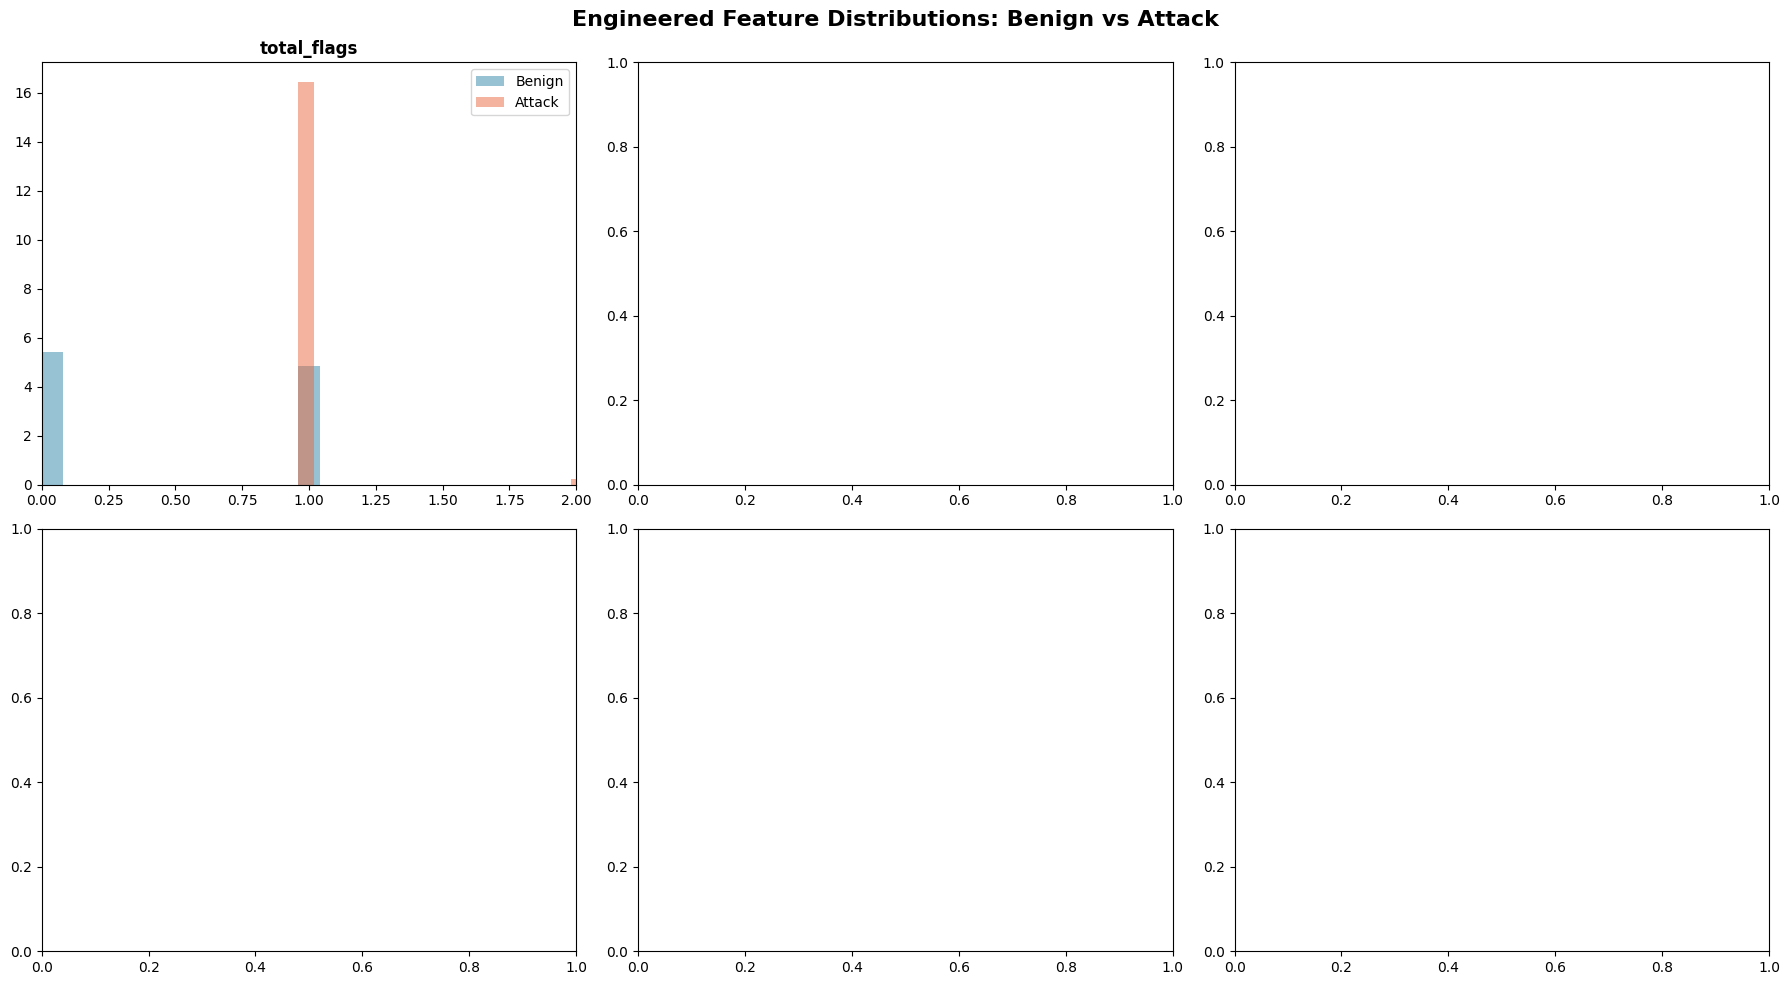

In [7]:
# ═══════════════════════════════════════════════════
# CELL 4 — Verify New Features
# ═══════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns

new_features = [f for f in engineer.engineered_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(new_features[:6]):
    ax = axes[i]

    benign = df[df['label_binary'] == 0][feat]
    attack = df[df['label_binary'] == 1][feat]

    ax.hist(benign, bins=50, alpha=0.5, label='Benign', color='#2E86AB', density=True)
    ax.hist(attack, bins=50, alpha=0.5, label='Attack', color='#E8683F', density=True)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_xlim(benign.quantile(0.01), benign.quantile(0.99))

plt.suptitle("Engineered Feature Distributions: Benign vs Attack",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("../notebooks/engineered_features.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ═══════════════════════════════════════════════════
# CELL 5 — Run Data Splitting Pipeline
# ═══════════════════════════════════════════════════
splitter = DataSplitter(
    processed_data_path="../data/processed/"
)

X_train, X_test, y_train, y_test = splitter.run_full_pipeline(
    mode='binary',
    balance=True
)


║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║
  NetSentinel — Data Splitting Pipeline
║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║║

LOADING PROCESSED DATA
  ✅ Loaded 2,520,798 rows, 51 columns

PREPARING FEATURES (binary mode)
  Features (X): (2520798, 48)
  Labels (y):   (2520798,)
  Label distribution:
    Class 0: 2,095,057 (83.1%)
    Class 1: 425,741 (16.9%)

SPLITTING DATA (test_size=0.2)
  Train: 2,016,638 samples
  Test:  504,160 samples

  Train label distribution:
    Class 0: 1,676,045 (83.1%)
    Class 1: 340,593 (16.9%)

SCALING FEATURES
  ✅ Features scaled (mean≈0, std≈1)
  Train sample means (first 5): [-0.  0. -0. -0.  0.]

BALANCING CLASSES (SMOTE)
  Before SMOTE:
    Class 0: 1,676,045
    Class 1: 340,593

  After SMOTE:
    Class 0: 1,676,045
    Class 1: 1,676,045

  ✅ Training data balanced
     Before: 2,016,638 samples
     After:  3,352,090 samples

SAVING SPLITS
  ✅ X_train.csv  (3,352,090 rows)
  ✅ X_test.csv   (504,160 rows)
 

In [9]:
# ═══════════════════════════════════════════════════
# CELL 6 — Final Verification
# ═══════════════════════════════════════════════════
import pandas as pd
import os

print("=" * 60)
print("FINAL VERIFICATION")
print("=" * 60)

processed_path = "../data/processed/"
files = os.listdir(processed_path)

print("\nFiles in data/processed/:")
for f in sorted(files):
    size = os.path.getsize(os.path.join(processed_path, f)) / (1024 * 1024)
    print(f"  → {f:35s} ({size:.1f} MB)")

print(f"\n  X_train shape: {X_train.shape}")
print(f"  X_test shape:  {X_test.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test shape:  {y_test.shape}")

print(f"\n  Feature count: {X_train.shape[1]}")
print(f"\n✅ Phase 2 Complete — Data is ML-ready!")

FINAL VERIFICATION

Files in data/processed/:
  → X_test.csv                          (474.0 MB)
  → X_train.csv                         (3146.1 MB)
  → cleaning_report.json                (0.0 MB)
  → processed_traffic.csv               (549.9 MB)
  → scaler.pkl                          (0.0 MB)
  → y_test.csv                          (1.0 MB)
  → y_train.csv                         (6.4 MB)

  X_train shape: (3352090, 48)
  X_test shape:  (504160, 48)
  y_train shape: (3352090,)
  y_test shape:  (504160,)

  Feature count: 48

✅ Phase 2 Complete — Data is ML-ready!
